In [5]:
# Cell 1: Setup and List Contents
import pandas as pd
import numpy as np
import os
from pathlib import Path

# Set the path to the unzipped data directory
data_path = r'C:\Users\riddh\Downloads\DA-E-Commerce-Data-Challenge-main'
print(f'Data directory: {data_path}')
print(f'Directory exists: {os.path.exists(data_path)}')
print(f'\nContents:')
for item in os.listdir(data_path):
    print(f'  - {item}')


Data directory: C:\Users\riddh\Downloads\DA-E-Commerce-Data-Challenge-main
Directory exists: True

Contents:
  - buyer.csv
  - LICENSE
  - metadata.pdf
  - sales.csv
  - Vendor Datasets


In [6]:
# Cell 4: Load Vendor Datasets
vendor_path = os.path.join(data_path, 'Vendor Datasets')
print(f'Vendor Datasets directory exists: {os.path.exists(vendor_path)}')

if os.path.exists(vendor_path):
    vendor_files = os.listdir(vendor_path)
    print(f'\nVendor dataset files:')
    for file in vendor_files:
        print(f'  - {file}')
    
    vendor_datasets = {}
    for file in vendor_files:
        if file.endswith('.csv'):
            file_path = os.path.join(vendor_path, file)
            vendor_datasets[file.replace('.csv', '')] = pd.read_csv(file_path)
            print(f'\nLoaded {file}: shape {vendor_datasets[file.replace(".csv", "")].shape}')


Vendor Datasets directory exists: True

Vendor dataset files:
  - CPSFP.csv
  - EYMKE.csv
  - JDTOJ.csv
  - JSCZL.csv
  - KWOXE.csv
  - NKDLI.csv
  - PQYYY.csv
  - ROPIK.csv
  - SOPAJ.csv
  - TAAFL.csv
  - WQEPS.csv

Loaded CPSFP.csv: shape (90, 11)

Loaded EYMKE.csv: shape (122, 11)

Loaded JDTOJ.csv: shape (129, 11)

Loaded JSCZL.csv: shape (18, 11)

Loaded KWOXE.csv: shape (111, 11)

Loaded NKDLI.csv: shape (46, 11)

Loaded PQYYY.csv: shape (42, 11)

Loaded ROPIK.csv: shape (95, 11)

Loaded SOPAJ.csv: shape (99, 11)

Loaded TAAFL.csv: shape (104, 11)

Loaded WQEPS.csv: shape (181, 11)


In [ ]:
# Combine Vendor Datasets into One Table
import glob

vendor_path = r'C:\Users\riddh\Downloads\DA-E-Commerce-Data-Challenge-main\Vendor Datasets'

# Get all CSV files from vendor datasets
vendor_files = glob.glob(f'{vendor_path}/*.csv')
print(f'Found {len(vendor_files)} vendor CSV files:\n')

vendor_dfs = []
for file in sorted(vendor_files):
    filename = file.split('\\')[-1]
    df = pd.read_csv(file)
    print(f'{filename:20} → {df.shape[0]:5} rows')
    vendor_dfs.append(df)

# Combine all vendor datasets into one table
products = pd.concat(vendor_dfs, ignore_index=True)

print(f'\n{"="*60}')
print(f'COMBINED VENDOR PRODUCTS TABLE')
print(f'{"="*60}')
print(f'Total rows: {products.shape[0]}')
print(f'Total columns: {products.shape[1]}')
print(f'\nColumns: {list(products.columns)}')
print(f'\nFirst 10 rows:')
print(products.head(10))
print(f'\nData types:')
print(products.dtypes)
print(f'\nBasic statistics:')
print(products.describe())


Found 11 vendor CSV files:

CPSFP.csv            →    90 rows
EYMKE.csv            →   122 rows
JDTOJ.csv            →   129 rows
JSCZL.csv            →    18 rows
KWOXE.csv            →   111 rows
NKDLI.csv            →    46 rows
PQYYY.csv            →    42 rows
ROPIK.csv            →    95 rows
SOPAJ.csv            →    99 rows
TAAFL.csv            →   104 rows
WQEPS.csv            →   181 rows

COMBINED VENDOR PRODUCTS TABLE


NameError: name 'products_combined' is not defined

PRODUCTS DATASET - DETAILED EDA

1) STRUCTURE
------------------------------------------------------------------------------------------
Shape: (1037, 12)
Columns: ['category_name', 'category_id', 'subcategory_name', 'subcategory_id', 'vendor', 'currently_active_vendor', 'product_num', 'price', 'profit_margin', 'active_product', 'current_stock', 'pct_profit_margin']

Dtypes:
category_name               object
category_id                 object
subcategory_name            object
subcategory_id              object
vendor                      object
currently_active_vendor     object
product_num                 object
price                       object
profit_margin              float64
active_product              object
current_stock                int64
pct_profit_margin           object
dtype: object

Sample rows:


,category_name,category_id,subcategory_name,subcategory_id,vendor,currently_active_vendor,product_num,price,profit_margin,active_product,current_stock,pct_profit_margin
0,Beauty,PBE,Skincare,PBESK,CPSFP,True,9DC69ECE1503,9.91,0.767131,True,90,NaN
1,Beauty,PBE,Skincare,PBESK,CPSFP,True,EF523B4FA026,13.42,0.767131,True,65,NaN
2,Beauty,PBE,Skincare,PBESK,CPSFP,True,C541AC8EF917,60.74,0.767131,True,29,NaN
3,Beauty,PBE,Skincare,PBESK,CPSFP,True,7CCFBF68193B,55.82,0.767131,True,91,NaN
4,Beauty,PBE,Skincare,PBESK,CPSFP,True,97FBE210389E,55.17,0.767131,True,17,NaN
5,Beauty,PBE,Skincare,PBESK,CPSFP,True,387CB7D445BD,19.2,0.767131,True,96,NaN
6,Beauty,PBE,Skincare,PBESK,CPSFP,True,719821503FFC,35.83,0.767131,True,44,NaN
7,Beauty,PBE,Skincare,PBESK,CPSFP,True,6493F730DD9E,52.72,0.767131,True,59,NaN
8,Beauty,PBE,Makeup,PBEMA,CPSFP,True,73042138ECC2,7.08,0.927131,True,153,NaN
9,Beauty,PBE,Makeup,PBEMA,CPSFP,True,0371E4072FCF,7.55,0.927131,True,59,NaN



2) DATA QUALITY: MISSING + DUPLICATES
------------------------------------------------------------------------------------------


,missing_rows,missing_pct
pct_profit_margin,813,78.4
profit_margin,224,21.6


Fully duplicate rows: 0
Duplicate rows on key ['product_num']: 432
Duplicate rows on key ['subcategory_id', 'product_num']: 432
Duplicate rows on key ['vendor', 'product_num']: 0

3) CATEGORICAL PROFILE
------------------------------------------------------------------------------------------

[category_name] unique values: 8
category_name
Beauty               182
Clothing             180
Home & Kitchen       155
Toys & Games         151
Sports & Outdoors    116
Books                104
Electronics           87
Pet Supplies          62
Name: count, dtype: int64

[category_id] unique values: 9
category_id
PBE    182
PCL    180
PHK    155
PTG    151
PBO    104
PLE     87
PSO     70
PPS     62
pso     46
Name: count, dtype: int64

[subcategory_name] unique values: 43
subcategory_name
Bath & Body            42
Makeup                 39
Hair care              35
Educational Toys       35
Dolls & Accessories    35
Fragrances             34
Climbing               34
Jackets                33


...


Category summary:


,products,avg_price,avg_pct_margin,avg_stock
category_name,,,,
Beauty,139,30.139828,41.055405,79.774725
Clothing,132,41.960000,NaN,68.611111
Home & Kitchen,129,107.979270,28.314106,53.741935
Sports & Outdoors,116,71.717845,NaN,53.517241
Toys & Games,113,60.406424,20.171124,57.688742
Books,78,38.198077,30.514517,73.557692
Electronics,64,217.238161,NaN,40.310345
Pet Supplies,50,27.121290,NaN,76.209677



Top subcategories by product count:


,products,avg_price,avg_stock
subcategory_name,,,
Climbing,34,66.720882,47.441176
Camping & Hiking,32,75.197187,56.843750
Makeup,29,24.578974,95.000000
Bath & Body,29,16.192381,90.023810
Cleaning Supplies,28,13.605313,95.781250
Fragrances,28,55.851875,61.382353
Cycling & Accessories,28,78.033571,52.678571
Hair care,27,19.766129,83.142857
Skincare,26,40.188667,63.625000



8) VISUAL CHECKS
------------------------------------------------------------------------------------------


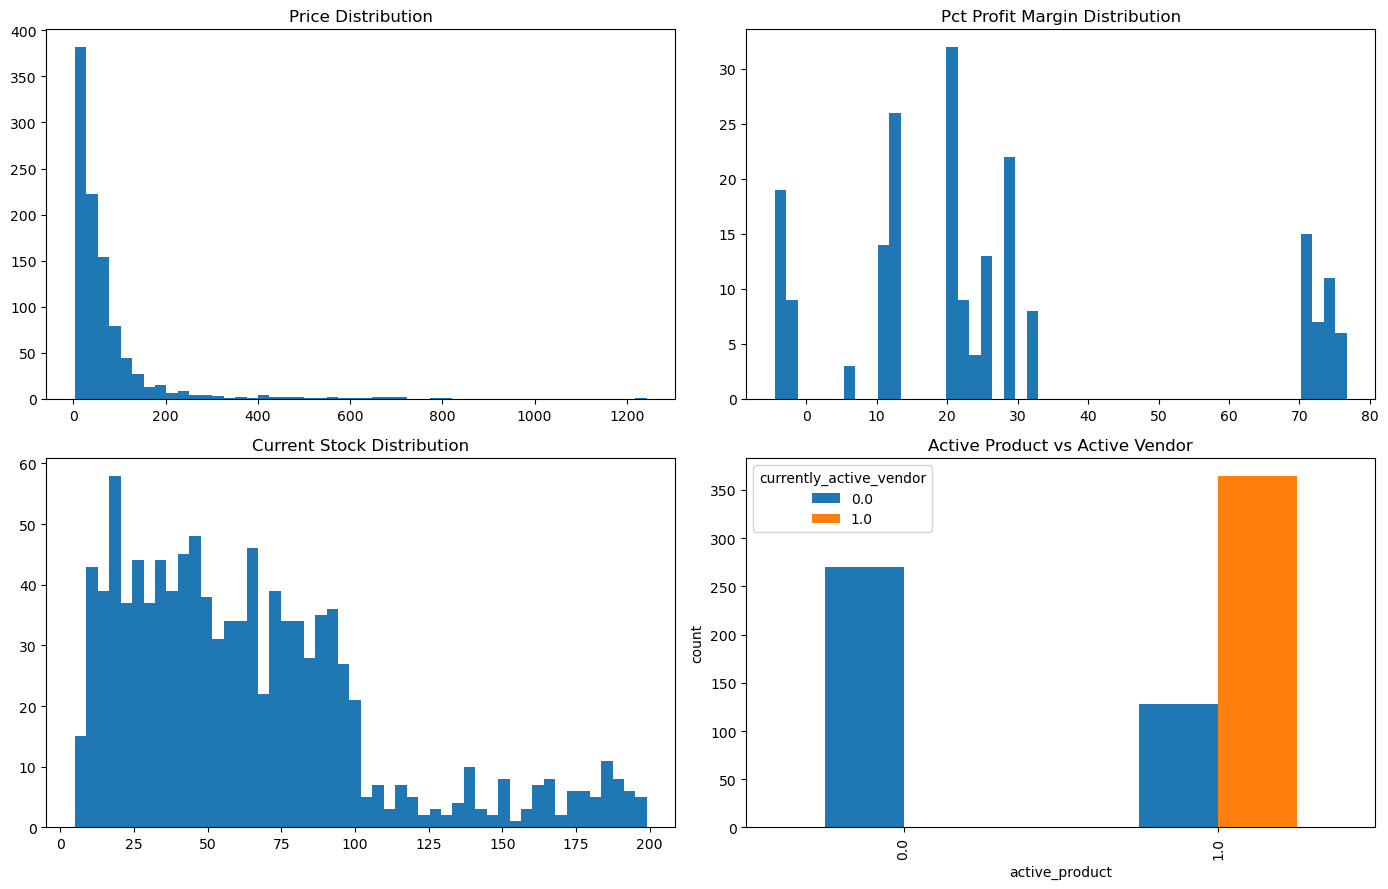


9) FINAL ISSUE TABLE
------------------------------------------------------------------------------------------


,issue,rows_affected,pct_of_data,severity,status
0,Missing product_num,0,0.00,HIGH,OK
1,Missing vendor,0,0.00,MEDIUM,OK
2,Missing category_id,0,0.00,MEDIUM,OK
3,Missing subcategory_id,0,0.00,MEDIUM,OK
6,price_negative,0,0.00,HIGH,OK
7,price_zero,0,0.00,MEDIUM,OK
8,stock_negative,0,0.00,HIGH,OK
11,pct_margin_gt100,0,0.00,MEDIUM,OK
14,category_id_maps_to_multiple_names,0,0.00,HIGH,OK
15,subcategory_id_maps_to_multiple_names,0,0.00,HIGH,OK



EDA complete.


In [ ]:
# DETAILED EDA FOR PRODUCTS DATASET
# Assumes dataframe name is: products
# If not loaded yet:
# products = pd.read_csv(os.path.join(data_path, "products.csv"))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)

df = products.copy()

print("="*90)
print("PRODUCTS DATASET - DETAILED EDA")
print("="*90)

# -----------------------------------------------------------------------------
# 1) STRUCTURE + BASIC INFO
# -----------------------------------------------------------------------------
print("\n1) STRUCTURE")
print("-"*90)
print("Shape:", df.shape)
print("Columns:", list(df.columns))
print("\nDtypes:")
print(df.dtypes)
print("\nSample rows:")
display(df.head(10))

# -----------------------------------------------------------------------------
# 2) MISSING VALUES + DUPLICATES
# -----------------------------------------------------------------------------
print("\n2) DATA QUALITY: MISSING + DUPLICATES")
print("-"*90)

missing = df.isna().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)
missing_summary = pd.DataFrame({"missing_rows": missing, "missing_pct": missing_pct})
display(missing_summary[missing_summary["missing_rows"] > 0])

print("Fully duplicate rows:", df.duplicated().sum())

# duplicate checks by potential keys
key_candidates = [
    ["product_num"],
    ["subcategory_id", "product_num"],
    ["vendor", "product_num"],
]
for key in key_candidates:
    if all(c in df.columns for c in key):
        dup_rows = df.duplicated(subset=key, keep=False).sum()
        print(f"Duplicate rows on key {key}: {dup_rows}")

# -----------------------------------------------------------------------------
# 3) CATEGORICAL PROFILE
# -----------------------------------------------------------------------------
print("\n3) CATEGORICAL PROFILE")
print("-"*90)

cat_cols = ["category_name", "category_id", "subcategory_name", "subcategory_id", "vendor",
            "currently_active_vendor", "active_product"]

for col in cat_cols:
    if col in df.columns:
        print(f"\n[{col}] unique values: {df[col].nunique(dropna=False)}")
        print(df[col].value_counts(dropna=False).head(10))

# Fix mixed-type columns before numeric checks (prevents '<' TypeError)


# Convert expected numeric columns safely
num_cols = ["price", "profit_margin", "pct_profit_margin", "current_stock", "active_product", "currently_active_vendor"]
for c in num_cols:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

# Now comparisons work
print("price_negative:", (df["price"] < 0).sum() if "price" in df.columns else "N/A")
print("stock_negative:", (df["current_stock"] < 0).sum() if "current_stock" in df.columns else "N/A")
print("pct_margin_gt100:", (df["pct_profit_margin"] > 100).sum() if "pct_profit_margin" in df.columns else "N/A")

# -----------------------------------------------------------------------------
# 4) NUMERIC PROFILE
# -----------------------------------------------------------------------------
print("\n4) NUMERIC PROFILE")
print("-"*90)

num_cols = ["price", "profit_margin", "pct_profit_margin", "current_stock"]
num_cols = [c for c in num_cols if c in df.columns]

if num_cols:
    display(df[num_cols].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).T)

# -----------------------------------------------------------------------------
# 5) LOGICAL CONSISTENCY CHECKS
# -----------------------------------------------------------------------------
print("\n5) LOGICAL CONSISTENCY CHECKS")
print("-"*90)

checks = {}

# Price & stock checks
if "price" in df.columns:
    checks["price_negative"] = (df["price"] < 0).sum()
    checks["price_zero"] = (df["price"] == 0).sum()

if "current_stock" in df.columns:
    checks["stock_negative"] = (df["current_stock"] < 0).sum()

# Margin checks
if "profit_margin" in df.columns:
    checks["profit_margin_negative"] = (df["profit_margin"] < 0).sum()

if "pct_profit_margin" in df.columns:
    checks["pct_margin_negative"] = (df["pct_profit_margin"] < 0).sum()
    checks["pct_margin_gt100"] = (df["pct_profit_margin"] > 100).sum()

# Active flag checks
if all(c in df.columns for c in ["active_product", "current_stock"]):
    checks["inactive_with_stock"] = ((df["active_product"] == 0) & (df["current_stock"] > 0)).sum()

if all(c in df.columns for c in ["currently_active_vendor", "active_product"]):
    checks["inactive_vendor_active_product"] = ((df["currently_active_vendor"] == 0) & (df["active_product"] == 1)).sum()

# ID-name one-to-one checks
if all(c in df.columns for c in ["category_id", "category_name"]):
    cat_map = df.groupby("category_id")["category_name"].nunique(dropna=False)
    checks["category_id_maps_to_multiple_names"] = (cat_map > 1).sum()

if all(c in df.columns for c in ["subcategory_id", "subcategory_name"]):
    subcat_map = df.groupby("subcategory_id")["subcategory_name"].nunique(dropna=False)
    checks["subcategory_id_maps_to_multiple_names"] = (subcat_map > 1).sum()

print(pd.Series(checks))

# -----------------------------------------------------------------------------
# 6) OUTLIER CHECKS (IQR METHOD)
# -----------------------------------------------------------------------------
print("\n6) OUTLIER CHECKS (IQR)")
print("-"*90)

def iqr_outlier_count(series):
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    low = q1 - 1.5 * iqr
    high = q3 + 1.5 * iqr
    return ((series < low) | (series > high)).sum(), low, high

for c in num_cols:
    s = df[c].dropna()
    if len(s) > 0:
        cnt, low, high = iqr_outlier_count(s)
        print(f"{c}: outliers={cnt:,}, lower={low:.4f}, upper={high:.4f}")

# -----------------------------------------------------------------------------
# 7) BUSINESS CUTS / SEGMENT SUMMARIES
# -----------------------------------------------------------------------------
print("\n7) SEGMENT SUMMARIES")
print("-"*90)

if all(c in df.columns for c in ["vendor", "product_num"]):
    vendor_summary = (
        df.groupby("vendor", dropna=False)
          .agg(
              products=("product_num", "nunique"),
              rows=("product_num", "size"),
              avg_price=("price", "mean") if "price" in df.columns else ("product_num", "size"),
              avg_stock=("current_stock", "mean") if "current_stock" in df.columns else ("product_num", "size"),
          )
          .sort_values("products", ascending=False)
    )
    print("\nTop vendors by unique products:")
    display(vendor_summary.head(15))

if all(c in df.columns for c in ["category_name", "product_num"]):
    cat_summary = (
        df.groupby("category_name", dropna=False)
          .agg(
              products=("product_num", "nunique"),
              avg_price=("price", "mean") if "price" in df.columns else ("product_num", "size"),
              avg_pct_margin=("pct_profit_margin", "mean") if "pct_profit_margin" in df.columns else ("product_num", "size"),
              avg_stock=("current_stock", "mean") if "current_stock" in df.columns else ("product_num", "size"),
          )
          .sort_values("products", ascending=False)
    )
    print("\nCategory summary:")
    display(cat_summary)

if all(c in df.columns for c in ["subcategory_name", "product_num"]):
    subcat_summary = (
        df.groupby("subcategory_name", dropna=False)
          .agg(
              products=("product_num", "nunique"),
              avg_price=("price", "mean") if "price" in df.columns else ("product_num", "size"),
              avg_stock=("current_stock", "mean") if "current_stock" in df.columns else ("product_num", "size"),
          )
          .sort_values("products", ascending=False)
    )
    print("\nTop subcategories by product count:")
    display(subcat_summary.head(20))

# -----------------------------------------------------------------------------
# 8) VISUAL CHECKS
# -----------------------------------------------------------------------------
print("\n8) VISUAL CHECKS")
print("-"*90)

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.flatten()

if "price" in df.columns:
    axes[0].hist(df["price"].dropna(), bins=50)
    axes[0].set_title("Price Distribution")
else:
    axes[0].axis("off")

if "pct_profit_margin" in df.columns:
    axes[1].hist(df["pct_profit_margin"].dropna(), bins=50)
    axes[1].set_title("Pct Profit Margin Distribution")
else:
    axes[1].axis("off")

if "current_stock" in df.columns:
    axes[2].hist(df["current_stock"].dropna(), bins=50)
    axes[2].set_title("Current Stock Distribution")
else:
    axes[2].axis("off")

if all(c in df.columns for c in ["active_product", "currently_active_vendor"]):
    ct = pd.crosstab(df["active_product"], df["currently_active_vendor"])
    ct.plot(kind="bar", ax=axes[3], title="Active Product vs Active Vendor")
    axes[3].set_xlabel("active_product")
    axes[3].set_ylabel("count")
else:
    axes[3].axis("off")

plt.tight_layout()
plt.show()

# -----------------------------------------------------------------------------
# 9) FINAL ISSUE TABLE (AUTO FLAG)
# -----------------------------------------------------------------------------
print("\n9) FINAL ISSUE TABLE")
print("-"*90)

issue_rows = []

def add_issue(name, count, severity="INFO"):
    issue_rows.append({
        "issue": name,
        "rows_affected": int(count),
        "pct_of_data": round(count / len(df) * 100, 2) if len(df) else 0,
        "severity": severity,
        "status": "CHECK" if count > 0 else "OK"
    })

# Missing critical fields
for c in ["product_num", "vendor", "category_id", "subcategory_id", "price"]:
    if c in df.columns:
        add_issue(f"Missing {c}", df[c].isna().sum(), "HIGH" if c in ["product_num", "price"] else "MEDIUM")

# Duplicates
if "product_num" in df.columns:
    add_issue("Duplicate product_num rows", df.duplicated(subset=["product_num"], keep=False).sum(), "HIGH")

# Logical issues from checks
for k, v in checks.items():
    sev = "HIGH" if ("negative" in k or "multiple_names" in k or "inactive_vendor_active_product" in k) else "MEDIUM"
    add_issue(k, v, sev)

issues_df = pd.DataFrame(issue_rows).sort_values(["status", "rows_affected"], ascending=[False, False])
display(issues_df)

print("\nEDA complete.")


In [ ]:
# Apply fuzzy standardization to ALL text columns in products
# (case/spacing normalization + fuzzy unification)

import pandas as pd
import re
from difflib import SequenceMatcher
from collections import Counter

df = products.copy()

def normalize_token(x):
    if pd.isna(x):
        return pd.NA
    s = str(x).strip()
    s = re.sub(r"\s+", " ", s)   # collapse spaces
    s = s.replace(" ", "")       # remove spaces for matching
    return s.upper()             # case-insensitive matching

def build_fuzzy_map_for_series(series, threshold=0.92):
    raw = series.astype("string")
    norm = raw.map(normalize_token)

    # frequency of normalized values
    freq = Counter(norm.dropna().tolist())
    tokens = sorted(freq.keys(), key=lambda t: (-freq[t], t))

    groups = []
    for tok in tokens:
        matched = False
        for g in groups:
            rep = g[0]
            if SequenceMatcher(None, tok, rep).ratio() >= threshold:
                g.append(tok)
                matched = True
                break
        if not matched:
            groups.append([tok])

    # canonical token per group = most frequent token
    token_to_canonical = {}
    for g in groups:
        canonical = sorted(g, key=lambda t: (-freq[t], t))[0]
        for t in g:
            token_to_canonical[t] = canonical

    # map raw -> canonical
    raw_to_canonical = {}
    for r, n in zip(raw, norm):
        if pd.isna(r):
            raw_to_canonical[r] = pd.NA
        else:
            raw_to_canonical[r] = token_to_canonical.get(n, n)

    return raw_to_canonical

# all text columns
text_cols = df.select_dtypes(include=["object", "string"]).columns.tolist()
print("Text columns:", text_cols)

# apply fuzzy mapping per text column
mapping_report = {}
for col in text_cols:
    before_unique = df[col].astype("string").nunique(dropna=False)
    mapper = build_fuzzy_map_for_series(df[col], threshold=0.92)
    df[col] = df[col].astype("string").map(mapper)
    after_unique = df[col].nunique(dropna=False)
    mapping_report[col] = {"before_unique": before_unique, "after_unique": after_unique}

# report
report_df = pd.DataFrame(mapping_report).T.sort_values("before_unique", ascending=False)
print("\nFuzzy standardization report:")
display(report_df)

# quick check key columns
for c in ["category_id", "vendor", "subcategory_id", "category_name", "subcategory_name"]:
    if c in df.columns:
        print(f"\n{c} top values:")
        print(df[c].value_counts(dropna=False).head(15))

# save back
products = df


Text columns: ['category_name', 'category_id', 'subcategory_name', 'subcategory_id', 'vendor', 'currently_active_vendor', 'product_num', 'price', 'active_product', 'pct_profit_margin']

Fuzzy standardization report:


,before_unique,after_unique
price,985,985
product_num,821,792
subcategory_id,47,43
subcategory_name,43,43
pct_profit_margin,22,14
vendor,11,11
category_id,9,8
category_name,8,8
active_product,5,5
currently_active_vendor,4,4



category_id top values:
category_id
PBE    182
PCL    180
PHK    155
PTG    151
PSO    116
PBO    104
PLE     87
PPS     62
Name: count, dtype: int64

vendor top values:
vendor
WQEPS    181
JDTOJ    129
EYMKE    122
KWOXE    111
TAAFL    104
SOPAJ     99
ROPIK     95
CPSFP     90
NKDLI     46
PQYYY     42
JSCZL     18
Name: count, dtype: int64

subcategory_id top values:
subcategory_id
PBEBA    42
PBEMA    39
PBEHA    35
PTGED    35
PTGDO    35
PBEFR    34
PSOCL    34
PCLJA    33
PBESK    32
PSOCA    32
PHKCL    32
PBOCH    29
PCLJE    29
PTGBU    29
PSOCY    28
Name: count, dtype: int64

category_name top values:
category_name
BEAUTY             182
CLOTHING           180
HOME&KITCHEN       155
TOYS&GAMES         151
SPORTS&OUTDOORS    116
BOOKS              104
ELECTRONICS         87
PETSUPPLIES         62
Name: count, dtype: int64

subcategory_name top values:
subcategory_name
BATH&BODY              42
MAKEUP                 39
HAIRCARE               35
EDUCATIONALTOYS        35
DO

In [ ]:
# Investigate encoding of active_product and currently_active_vendor (no fixes)

import pandas as pd

df = products.copy()

# 1) Raw value distribution
for col in ["active_product", "currently_active_vendor"]:
    print(f"\n=== {col} raw value counts ===")
    print(df[col].value_counts(dropna=False).sort_index())

# 2) Coerce to numeric to detect non-numeric encodings
for col in ["active_product", "currently_active_vendor"]:
    df[f"{col}_num"] = pd.to_numeric(df[col], errors="coerce")

for col in ["active_product", "currently_active_vendor"]:
    bad_mask = df[col].notna() & df[f"{col}_num"].isna()
    print(f"\n{col}: non-numeric rows =", bad_mask.sum())
    if bad_mask.sum() > 0:
        print(df.loc[bad_mask, [col]].drop_duplicates().head(20))

# 3) Check if values are strictly binary {0,1}
for col in ["active_product_num", "currently_active_vendor_num"]:
    valid_mask = df[col].isin([0, 1]) | df[col].isna()
    invalid_count = (~valid_mask).sum()
    print(f"\n{col}: invalid (not 0/1/NaN) rows =", invalid_count)
    if invalid_count > 0:
        print(df.loc[~valid_mask, [col]].value_counts().head(20))

# 4) Relationship between both flags
print("\n=== Crosstab: active_product vs currently_active_vendor ===")
ct = pd.crosstab(
    df["active_product_num"],
    df["currently_active_vendor_num"],
    dropna=False
)
print(ct)

# 5) Potentially inconsistent combos
# Example business assumption to test: active product should not come from inactive vendor
inconsistent = df[
    (df["active_product_num"] == 1) &
    (df["currently_active_vendor_num"] == 0)
].copy()

print("\nRows with active_product=1 and currently_active_vendor=0:", len(inconsistent))
display(inconsistent.head(30))

# 6) Optional profile of inconsistent rows
if len(inconsistent) > 0:
    print("\nInconsistent rows by vendor:")
    print(inconsistent["vendor"].value_counts(dropna=False).head(20))
    print("\nInconsistent rows by category_id:")
    print(inconsistent["category_id"].value_counts(dropna=False).head(20))



=== active_product raw value counts ===
active_product
0         13
1         16
FALSE    340
TRUE     546
Y        122
Name: count, dtype: int64

=== currently_active_vendor raw value counts ===
currently_active_vendor
0         29
FALSE    521
TRUE     365
Y        122
Name: count, dtype: int64

active_product: non-numeric rows = 1008
    active_product
0             TRUE
90               Y
238          FALSE

currently_active_vendor: non-numeric rows = 1008
    currently_active_vendor
0                      TRUE
90                        Y
212                   FALSE

active_product_num: invalid (not 0/1/NaN) rows = 0

currently_active_vendor_num: invalid (not 0/1/NaN) rows = 0

=== Crosstab: active_product vs currently_active_vendor ===
currently_active_vendor_num  0.0   NaN
active_product_num                    
0.0                           13     0
1.0                           16     0
NaN                            0  1008

Rows with active_product=1 and currently_active_vend

,category_name,category_id,subcategory_name,subcategory_id,vendor,currently_active_vendor,product_num,price,profit_margin,active_product,current_stock,pct_profit_margin,active_product_num,currently_active_vendor_num
859,BEAUTY,PBE,MAKEUP,PBEMA,WQEPS,0,FA7A134CB806,9.72,0.927131,1,148,<NA>,1.0,0.0
871,CLOTHING,PCL,JACKETS,PCLJA,WQEPS,0,2FC8794FBF1A,140.33,0.153923,1,32,<NA>,1.0,0.0
881,CLOTHING,PCL,HOODIES,PCLHO,WQEPS,0,CE4497AB4613,54.89,0.273923,1,84,<NA>,1.0,0.0
882,CLOTHING,PCL,HOODIES,PCLHO,WQEPS,0,5B1B0273CC52,21.87,0.273923,1,75,<NA>,1.0,0.0
886,CLOTHING,PCL,SHOES,PCLSH,WQEPS,0,D8CFED921422,28.73,0.153923,1,62,<NA>,1.0,0.0
917,BEAUTY,PBE,BATH&BODY,PBEBA,WQEPS,0,9DC4310B3F51,6.71,0.293923,1,186,<NA>,1.0,0.0
921,BEAUTY,PBE,BATH&BODY,PBEBA,WQEPS,0,6CDF1D42E724,15.51,0.293923,1,127,<NA>,1.0,0.0
930,BEAUTY,PBE,BATH&BODY,PBEBA,WQEPS,0,A3267F48D1C0,16.95,0.293923,1,39,<NA>,1.0,0.0
936,BEAUTY,PBE,BATH&BODY,PBEBA,WQEPS,0,055F34332439,28.86,0.293923,1,86,<NA>,1.0,0.0
975,CLOTHING,PCL,TSHIRTS,PCLTS,WQEPS,0,455C59306194,7.82,0.737131,1,49,<NA>,1.0,0.0



Inconsistent rows by vendor:
vendor
WQEPS    16
Name: count, dtype: int64

Inconsistent rows by category_id:
category_id
PCL    7
PBE    5
PPS    4
Name: count, dtype: int64


In [ ]:
mapping = {
    '1': 1, 1: 1, 'true': 1, 'TRUE': 1, 'y': 1, 'Y': 1,
    '0': 0, 0: 0, 'false': 0, 'FALSE': 0, 'n': 0, 'N': 0
}

In [ ]:
def normalize_bool(col):
    return (
        col.astype(str)
           .str.strip()
           .str.lower()
           .map(mapping)
    )

products['active_product_num'] = normalize_bool(df['active_product'])
products['currently_active_vendor_num'] = normalize_bool(df['currently_active_vendor'])

In [ ]:
print(products['active_product_num'].value_counts(dropna=False))
print(products['currently_active_vendor_num'].value_counts(dropna=False))

active_product_num
1    684
0    353
Name: count, dtype: int64
currently_active_vendor_num
0    550
1    487
Name: count, dtype: int64


In [ ]:
pd.crosstab(products['active_product_num'], products['currently_active_vendor_num'])

currently_active_vendor_num,0,1
active_product_num,,
0,353,0
1,197,487


In [ ]:
products['vendor_product_conflict'] = (
    (products['active_product_num'] == 1) & 
    (products['currently_active_vendor_num'] == 0)
)

In [ ]:
products

,category_name,category_id,subcategory_name,subcategory_id,vendor,currently_active_vendor,product_num,price,profit_margin,active_product,current_stock,pct_profit_margin,active_product_num,currently_active_vendor_num,vendor_product_conflict,logic_issue
0,BEAUTY,PBE,SKINCARE,PBESK,CPSFP,TRUE,9DC69ECE1503,9.91,0.767131,TRUE,90,<NA>,1,1,False,False
1,BEAUTY,PBE,SKINCARE,PBESK,CPSFP,TRUE,EF523B4FA026,13.42,0.767131,TRUE,65,<NA>,1,1,False,False
2,BEAUTY,PBE,SKINCARE,PBESK,CPSFP,TRUE,C541AC8EF917,60.74,0.767131,TRUE,29,<NA>,1,1,False,False
3,BEAUTY,PBE,SKINCARE,PBESK,CPSFP,TRUE,7CCFBF68193B,55.82,0.767131,TRUE,91,<NA>,1,1,False,False
4,BEAUTY,PBE,SKINCARE,PBESK,CPSFP,TRUE,97FBE210389E,55.17,0.767131,TRUE,17,<NA>,1,1,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1032,PETSUPPLIES,PPS,LITTER&WASTEDISPOSAL,PPSLI,WQEPS,FALSE,B86E5FB5699B,31.76,0.083923,FALSE,41,<NA>,0,0,False,False
1033,PETSUPPLIES,PPS,LITTER&WASTEDISPOSAL,PPSLI,WQEPS,FALSE,D642806A616B,50.94,0.083923,FALSE,45,<NA>,0,0,False,False
1034,PETSUPPLIES,PPS,BEDS&FURNITURES,PPSBE,WQEPS,0,4B231BB83428,46.1,0.073923,1,46,<NA>,1,0,True,True
1035,PETSUPPLIES,PPS,TOYS,PPSTO,WQEPS,0,0DF76495E861,10.84,-0.034388,1,135,<NA>,1,0,True,True


In [ ]:
# Null count
print("Null pct_profit_margin:", products["pct_profit_margin"].isna().sum())

# Null percentage
print(
    "Null % pct_profit_margin:",
    round(products["pct_profit_margin"].isna().mean() * 100, 2),
    "%"
)

# View rows where pct_profit_margin is null
products[products["pct_profit_margin"].isna()].head(20)


Null pct_profit_margin: 813
Null % pct_profit_margin: 78.4 %


,category_name,category_id,subcategory_name,subcategory_id,vendor,currently_active_vendor,product_num,price,profit_margin,active_product,current_stock,pct_profit_margin,active_product_num,currently_active_vendor_num,vendor_product_conflict
0,BEAUTY,PBE,SKINCARE,PBESK,CPSFP,TRUE,9DC69ECE1503,9.91,0.767131,TRUE,90,<NA>,1,1,False
1,BEAUTY,PBE,SKINCARE,PBESK,CPSFP,TRUE,EF523B4FA026,13.42,0.767131,TRUE,65,<NA>,1,1,False
2,BEAUTY,PBE,SKINCARE,PBESK,CPSFP,TRUE,C541AC8EF917,60.74,0.767131,TRUE,29,<NA>,1,1,False
3,BEAUTY,PBE,SKINCARE,PBESK,CPSFP,TRUE,7CCFBF68193B,55.82,0.767131,TRUE,91,<NA>,1,1,False
4,BEAUTY,PBE,SKINCARE,PBESK,CPSFP,TRUE,97FBE210389E,55.17,0.767131,TRUE,17,<NA>,1,1,False
5,BEAUTY,PBE,SKINCARE,PBESK,CPSFP,TRUE,387CB7D445BD,19.2,0.767131,TRUE,96,<NA>,1,1,False
6,BEAUTY,PBE,SKINCARE,PBESK,CPSFP,TRUE,719821503FFC,35.83,0.767131,TRUE,44,<NA>,1,1,False
7,BEAUTY,PBE,SKINCARE,PBESK,CPSFP,TRUE,6493F730DD9E,52.72,0.767131,TRUE,59,<NA>,1,1,False
8,BEAUTY,PBE,MAKEUP,PBEMA,CPSFP,TRUE,73042138ECC2,7.08,0.927131,TRUE,153,<NA>,1,1,False
9,BEAUTY,PBE,MAKEUP,PBEMA,CPSFP,TRUE,0371E4072FCF,7.55,0.927131,TRUE,59,<NA>,1,1,False


In [ ]:
# Check if pct_profit_margin = profit_margin * 100
both = products[products['profit_margin'].notna() & 
                products['pct_profit_margin'].notna()].copy()

products['pct_profit_margin'] = pd.to_numeric(products['pct_profit_margin'], errors='coerce')

both['derived'] = both['profit_margin'] * 100
both['difference'] = (both['pct_profit_margin'] - both['derived']).abs()

print(f"Rows where both exist: {len(both)}")
print(f"Max difference: {both['difference'].max()}")
print(f"Mean difference: {both['difference'].mean()}")
print(f"Perfect matches (diff < 0.001): {(both['difference'] < 0.001).sum()}")

Rows where both exist: 0
Max difference: nan
Mean difference: nan
Perfect matches (diff < 0.001): 0


In [ ]:
# Which vendors use which column?
print("profit_margin populated by vendor:")
print(products[products['profit_margin'].notna()]['vendor'].value_counts())

print("\npct_profit_margin populated by vendor:")
print(products[products['pct_profit_margin'].notna()]['vendor'].value_counts())

profit_margin populated by vendor:
vendor
WQEPS    181
EYMKE    122
KWOXE    111
TAAFL    104
SOPAJ     99
CPSFP     90
NKDLI     46
PQYYY     42
JSCZL     18
Name: count, dtype: int64

pct_profit_margin populated by vendor:
vendor
JDTOJ    129
ROPIK     80
Name: count, dtype: int64


In [ ]:
# Convert pct_profit_margin to decimal scale to match profit_margin
products['pct_profit_margin'] = pd.to_numeric(
    products['pct_profit_margin'], errors='coerce'
)

# Unify: use profit_margin first, fill gaps with pct/100
products['margin'] = products['profit_margin'].fillna(
    products['pct_profit_margin'] / 100
)

print(f"Valid margin: {products['margin'].notna().sum()}")
print(f"Null margin:  {products['margin'].isna().sum()}")
print(f"\nBy vendor:")
print(products.groupby('vendor')['margin'].agg(['count','mean']).round(3))

Valid margin: 1022
Null margin:  15

By vendor:
        count   mean
vendor              
CPSFP      90  0.407
EYMKE     122  0.304
JDTOJ     129  0.209
JSCZL      18  0.767
KWOXE     111  0.252
NKDLI      46  0.254
PQYYY      42  0.042
ROPIK      80  0.258
SOPAJ      99  0.312
TAAFL     104  0.294
WQEPS     181  0.329


In [ ]:
products

,category_name,category_id,subcategory_name,subcategory_id,vendor,currently_active_vendor,product_num,price,profit_margin,active_product,current_stock,pct_profit_margin,active_product_num,currently_active_vendor_num,vendor_product_conflict,margin
0,BEAUTY,PBE,SKINCARE,PBESK,CPSFP,TRUE,9DC69ECE1503,9.91,0.767131,TRUE,90,NaN,1,1,False,0.767131
1,BEAUTY,PBE,SKINCARE,PBESK,CPSFP,TRUE,EF523B4FA026,13.42,0.767131,TRUE,65,NaN,1,1,False,0.767131
2,BEAUTY,PBE,SKINCARE,PBESK,CPSFP,TRUE,C541AC8EF917,60.74,0.767131,TRUE,29,NaN,1,1,False,0.767131
3,BEAUTY,PBE,SKINCARE,PBESK,CPSFP,TRUE,7CCFBF68193B,55.82,0.767131,TRUE,91,NaN,1,1,False,0.767131
4,BEAUTY,PBE,SKINCARE,PBESK,CPSFP,TRUE,97FBE210389E,55.17,0.767131,TRUE,17,NaN,1,1,False,0.767131
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1032,PETSUPPLIES,PPS,LITTER&WASTEDISPOSAL,PPSLI,WQEPS,FALSE,B86E5FB5699B,31.76,0.083923,FALSE,41,NaN,0,0,False,0.083923
1033,PETSUPPLIES,PPS,LITTER&WASTEDISPOSAL,PPSLI,WQEPS,FALSE,D642806A616B,50.94,0.083923,FALSE,45,NaN,0,0,False,0.083923
1034,PETSUPPLIES,PPS,BEDS&FURNITURES,PPSBE,WQEPS,0,4B231BB83428,46.1,0.073923,1,46,NaN,1,0,True,0.073923
1035,PETSUPPLIES,PPS,TOYS,PPSTO,WQEPS,0,0DF76495E861,10.84,-0.034388,1,135,NaN,1,0,True,-0.034388


In [ ]:
# Check missing pct_profit_margin rows for vendor ROPIK (fixed code)

ropik_missing = products[
    (products["vendor"] == "ROPIK") &
    (products["pct_profit_margin"].isna())
].copy()

print(f"Missing ROPIK pct_profit_margin rows: {len(ropik_missing)}")

# show only columns that actually exist in your dataframe
cols = [
    "category_name", "category_id",
    "subcategory_name", "subcategory_id",
    "vendor", "currently_active_vendor",
    "product_num", "price", "profit_margin",
    "pct_profit_margin", "active_product", "current_stock",
    "active_product_num", "currently_active_vendor_num",
    "vendor_product_conflict"
]
cols = [c for c in cols if c in products.columns]

print(ropik_missing[cols].head(15))

# Are they concentrated in specific subcategories?
print("\nSubcategory distribution:")
print(ropik_missing["subcategory_name"].value_counts(dropna=False))


Missing ROPIK pct_profit_margin rows: 15
    category_name category_id subcategory_name subcategory_id vendor  \
584  HOME&KITCHEN         PHK         COOKWARE          PHKCO  ROPIK   
585  HOME&KITCHEN         PHK         COOKWARE          PHKCO  ROPIK   
586  HOME&KITCHEN         PHK         COOKWARE          PHKCO  ROPIK   
587  HOME&KITCHEN         PHK         COOKWARE          PHKCO  ROPIK   
588  HOME&KITCHEN         PHK         COOKWARE          PHKCO  ROPIK   
589  HOME&KITCHEN         PHK         COOKWARE          PHKCO  ROPIK   
590  HOME&KITCHEN         PHK         COOKWARE          PHKCO  ROPIK   
591  HOME&KITCHEN         PHK         COOKWARE          PHKCO  ROPIK   
592  HOME&KITCHEN         PHK         COOKWARE          PHKCO  ROPIK   
593  HOME&KITCHEN         PHK         COOKWARE          PHKCO  ROPIK   
594  HOME&KITCHEN         PHK         COOKWARE          PHKCO  ROPIK   
595  HOME&KITCHEN         PHK         COOKWARE          PHKCO  ROPIK   
596  HOME&KITCHEN      

In [ ]:
cookware = df[
    df["subcategory_name"].astype("string")
    .str.contains("cookware", case=False, na=False)
].copy()
cookware["vendor_clean"] = (
    cookware["vendor"]
    .astype("string")
    .str.strip()
    .str.upper()
)
ropik = cookware[cookware["vendor_clean"].str.contains(r"\bROPIK\b", na=False)]
other = cookware[~cookware["vendor_clean"].str.contains(r"\bROPIK\b", na=False)]
print("ROPIK rows:", len(ropik))
print("ROPIK non-null profit_margin:", ropik["profit_margin"].notna().sum())

print("OTHER rows:", len(other))
print("OTHER non-null profit_margin:", other["profit_margin"].notna().sum())
other_summary = (
    other[other["profit_margin"].notna()]
    .groupby("vendor_clean")
    .agg(
        count=("profit_margin", "count"),
        mean_margin=("profit_margin", "mean"),
        median_margin=("profit_margin", "median")
    )
    .sort_values("mean_margin", ascending=False)
)

print(other_summary)

ROPIK rows: 15
ROPIK non-null profit_margin: 0
OTHER rows: 7
OTHER non-null profit_margin: 7
              count  mean_margin  median_margin
vendor_clean                                   
EYMKE             7     0.727131       0.727131


In [ ]:
# Which vendors/subcategories have missing price?
missing_price = products[products['price'].isna()]
print(missing_price['vendor'].value_counts())
print(missing_price['subcategory_name'].value_counts())

Series([], Name: count, dtype: int64)
Series([], Name: count, dtype: int64)


In [ ]:
# Check missing price thoroughly

missing_price = products[products["price"].isna()].copy()

print("Missing price rows:", len(missing_price))
print("Missing price %:", round(len(missing_price) / len(products) * 100, 2), "%")

print("\nBy vendor:")
print(missing_price["vendor"].value_counts(dropna=False))

print("\nBy subcategory_name:")
print(missing_price["subcategory_name"].value_counts(dropna=False))

# Optional: inspect full rows
display(
    missing_price[
        [
            "category_name", "category_id",
            "subcategory_name", "subcategory_id",
            "vendor", "product_num",
            "price", "profit_margin", "pct_profit_margin",
            "active_product", "current_stock"
        ]
    ].head(30)
)


Missing price rows: 0
Missing price %: 0.0 %

By vendor:
Series([], Name: count, dtype: int64)

By subcategory_name:
Series([], Name: count, dtype: int64)


,category_name,category_id,subcategory_name,subcategory_id,vendor,product_num,price,profit_margin,pct_profit_margin,active_product,current_stock


In [ ]:
# Create composite key sku_id in products to match sales
# sku_id = subcategory_id - vendor - product_num

for col in ["subcategory_id", "vendor", "product_num"]:
    products[col] = products[col].astype("string").str.strip()

products["sku_id"] = (
    products["subcategory_id"] + "-" +
    products["vendor"] + "-" +
    products["product_num"]
)

# Validation
print("sku_id created.")
print("Null sku_id rows:", products["sku_id"].isna().sum())
print("Duplicate sku_id rows:", products.duplicated(subset=["sku_id"], keep=False).sum())
print(products[["subcategory_id", "vendor", "product_num", "sku_id"]].head(10))


sku_id created.
Null sku_id rows: 0
Duplicate sku_id rows: 0
  subcategory_id vendor   product_num                    sku_id
0          PBESK  CPSFP  9DC69ECE1503  PBESK-CPSFP-9DC69ECE1503
1          PBESK  CPSFP  EF523B4FA026  PBESK-CPSFP-EF523B4FA026
2          PBESK  CPSFP  C541AC8EF917  PBESK-CPSFP-C541AC8EF917
3          PBESK  CPSFP  7CCFBF68193B  PBESK-CPSFP-7CCFBF68193B
4          PBESK  CPSFP  97FBE210389E  PBESK-CPSFP-97FBE210389E
5          PBESK  CPSFP  387CB7D445BD  PBESK-CPSFP-387CB7D445BD
6          PBESK  CPSFP  719821503FFC  PBESK-CPSFP-719821503FFC
7          PBESK  CPSFP  6493F730DD9E  PBESK-CPSFP-6493F730DD9E
8          PBEMA  CPSFP  73042138ECC2  PBEMA-CPSFP-73042138ECC2
9          PBEMA  CPSFP  0371E4072FCF  PBEMA-CPSFP-0371E4072FCF


In [ ]:
neg_margin = products[products['margin'] < 0]
print(f"Negative margin rows: {len(neg_margin)}")
print(neg_margin[['vendor', 'subcategory_name', 
                  'margin', 'price', 'active_product']].head(10))
print(neg_margin['vendor'].value_counts())
print(neg_margin['subcategory_name'].value_counts())

Negative margin rows: 111
    vendor subcategory_name    margin  price active_product
230  JDTOJ      NON-FICTION -0.024388  19.32           TRUE
231  JDTOJ      NON-FICTION -0.024388  25.63           TRUE
232  JDTOJ      NON-FICTION -0.024388  21.72           TRUE
233  JDTOJ      NON-FICTION -0.024388  25.25           TRUE
234  JDTOJ      NON-FICTION -0.024388  26.83           TRUE
235  JDTOJ      NON-FICTION -0.024388  27.53           TRUE
236  JDTOJ      NON-FICTION -0.024388  34.96           TRUE
237  JDTOJ      NON-FICTION -0.024388  30.26           TRUE
271  JDTOJ      NON-FICTION -0.024388   28.1          FALSE
311  JDTOJ  EDUCATIONALTOYS -0.044388  65.78           TRUE
vendor
JDTOJ    28
SOPAJ    21
KWOXE    19
TAAFL    16
PQYYY    14
NKDLI    11
WQEPS     2
Name: count, dtype: Int64
subcategory_name
EDUCATIONALTOYS    35
CAMPING&HIKING     32
NON-FICTION        28
TOYS               16
Name: count, dtype: int64


Negative profit_margin rows: 83
Negative pct_profit_margin rows: 28

profit_margin distribution:
count    813.000000
mean       0.307436
std        0.269487
min       -0.044388
1%        -0.044388
5%        -0.024388
25%        0.123923
50%        0.223923
75%        0.373923
95%        0.787131
99%        0.927131
max        0.927131
Name: profit_margin, dtype: float64

pct_profit_margin distribution:
count    209.000000
mean      22.770284
std       23.073739
min       -4.438807
1%        -4.438807
5%        -4.438807
25%       12.392327
50%       12.392327
75%       22.392327
95%       73.713100
99%       76.713100
max       76.713100
Name: pct_profit_margin, dtype: float64


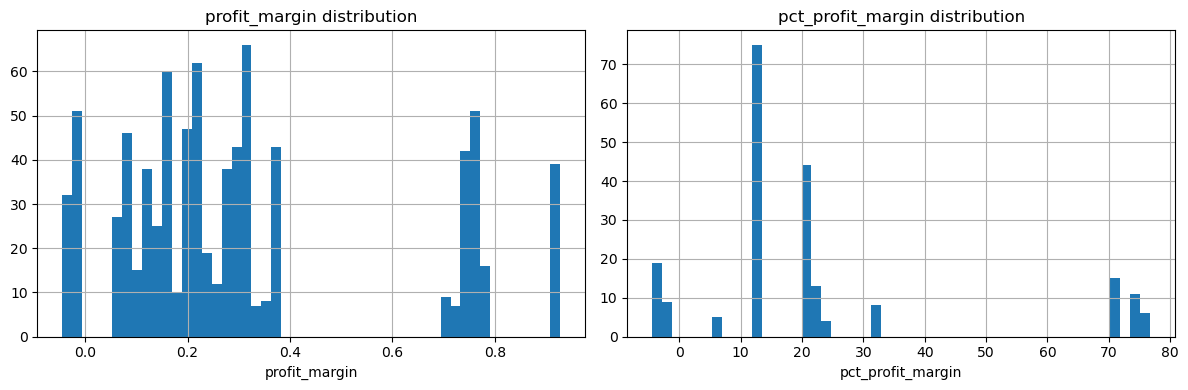

In [ ]:
# Use correct columns: profit_margin and pct_profit_margin (not 'margin')

import pandas as pd
import matplotlib.pyplot as plt

# Ensure numeric
products["profit_margin"] = pd.to_numeric(products["profit_margin"], errors="coerce")
products["pct_profit_margin"] = pd.to_numeric(products["pct_profit_margin"], errors="coerce")

# Negative margin rows
neg_margin = products[products["profit_margin"] < 0].copy()
neg_pct_margin = products[products["pct_profit_margin"] < 0].copy()

print("Negative profit_margin rows:", len(neg_margin))
print("Negative pct_profit_margin rows:", len(neg_pct_margin))

# Distribution summary
print("\nprofit_margin distribution:")
print(products["profit_margin"].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]))

print("\npct_profit_margin distribution:")
print(products["pct_profit_margin"].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]))

# Histograms
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
products["profit_margin"].dropna().hist(bins=50, ax=ax[0])
ax[0].set_title("profit_margin distribution")
ax[0].set_xlabel("profit_margin")

products["pct_profit_margin"].dropna().hist(bins=50, ax=ax[1])
ax[1].set_title("pct_profit_margin distribution")
ax[1].set_xlabel("pct_profit_margin")

plt.tight_layout()
plt.show()


In [ ]:
neg_margin = products[products['margin'] < 0]
print(neg_margin['margin'].describe())
print(neg_margin['margin'].value_counts())

count    111.000000
mean      -0.032136
std        0.009014
min       -0.044388
25%       -0.044388
50%       -0.024388
75%       -0.024388
max       -0.024388
Name: margin, dtype: float64
margin
-0.024388    60
-0.044388    35
-0.034388    16
Name: count, dtype: int64


In [ ]:
products['is_loss_product'] = products['margin'] < 0

# Verify
print(products['is_loss_product'].value_counts())
print(f"\nLoss products by vendor:")
print(products[products['is_loss_product']]['vendor'].value_counts())
print(f"\nLoss products by subcategory:")
print(products[products['is_loss_product']]['subcategory_name'].value_counts())

is_loss_product
False    926
True     111
Name: count, dtype: int64

Loss products by vendor:
vendor
JDTOJ    28
SOPAJ    21
KWOXE    19
TAAFL    16
PQYYY    14
NKDLI    11
WQEPS     2
Name: count, dtype: Int64

Loss products by subcategory:
subcategory_name
EDUCATIONALTOYS    35
CAMPING&HIKING     32
NON-FICTION        28
TOYS               16
Name: count, dtype: int64


In [ ]:
products

,category_name,category_id,subcategory_name,subcategory_id,vendor,currently_active_vendor,product_num,price,profit_margin,active_product,current_stock,pct_profit_margin,active_product_num,currently_active_vendor_num,vendor_product_conflict,margin,sku_id,is_loss_product
0,BEAUTY,PBE,SKINCARE,PBESK,CPSFP,TRUE,9DC69ECE1503,9.91,0.767131,TRUE,90,NaN,1,1,False,0.767131,PBESK-CPSFP-9DC69ECE1503,False
1,BEAUTY,PBE,SKINCARE,PBESK,CPSFP,TRUE,EF523B4FA026,13.42,0.767131,TRUE,65,NaN,1,1,False,0.767131,PBESK-CPSFP-EF523B4FA026,False
2,BEAUTY,PBE,SKINCARE,PBESK,CPSFP,TRUE,C541AC8EF917,60.74,0.767131,TRUE,29,NaN,1,1,False,0.767131,PBESK-CPSFP-C541AC8EF917,False
3,BEAUTY,PBE,SKINCARE,PBESK,CPSFP,TRUE,7CCFBF68193B,55.82,0.767131,TRUE,91,NaN,1,1,False,0.767131,PBESK-CPSFP-7CCFBF68193B,False
4,BEAUTY,PBE,SKINCARE,PBESK,CPSFP,TRUE,97FBE210389E,55.17,0.767131,TRUE,17,NaN,1,1,False,0.767131,PBESK-CPSFP-97FBE210389E,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1032,PETSUPPLIES,PPS,LITTER&WASTEDISPOSAL,PPSLI,WQEPS,FALSE,B86E5FB5699B,31.76,0.083923,FALSE,41,NaN,0,0,False,0.083923,PPSLI-WQEPS-B86E5FB5699B,False
1033,PETSUPPLIES,PPS,LITTER&WASTEDISPOSAL,PPSLI,WQEPS,FALSE,D642806A616B,50.94,0.083923,FALSE,45,NaN,0,0,False,0.083923,PPSLI-WQEPS-D642806A616B,False
1034,PETSUPPLIES,PPS,BEDS&FURNITURES,PPSBE,WQEPS,0,4B231BB83428,46.1,0.073923,1,46,NaN,1,0,True,0.073923,PPSBE-WQEPS-4B231BB83428,False
1035,PETSUPPLIES,PPS,TOYS,PPSTO,WQEPS,0,0DF76495E861,10.84,-0.034388,1,135,NaN,1,0,True,-0.034388,PPSTO-WQEPS-0DF76495E861,True


In [ ]:
# Analyze inactive products that still have stock > 0

import pandas as pd

df = products.copy()

# Ensure numeric flags/stock
df["active_product_num"] = pd.to_numeric(df["active_product"], errors="coerce")
df["current_stock_num"] = pd.to_numeric(df["current_stock"], errors="coerce")

# Flag condition
inactive_with_stock = df[
    (df["active_product_num"] == 0) &
    (df["current_stock_num"] > 0)
].copy()

print("Inactive products with stock > 0:", len(inactive_with_stock))
print("Percent of dataset:", round(len(inactive_with_stock) / len(df) * 100, 2), "%")

# Summary stats
print("\nStock stats for flagged rows:")
print(inactive_with_stock["current_stock_num"].describe())

print("\nPrice stats for flagged rows:")
print(pd.to_numeric(inactive_with_stock["price"], errors="coerce").describe())

# By vendor
print("\nTop vendors:")
print(inactive_with_stock["vendor"].value_counts(dropna=False).head(20))

# By category/subcategory
print("\nTop categories:")
print(inactive_with_stock["category_name"].value_counts(dropna=False).head(15))

print("\nTop subcategories:")
print(inactive_with_stock["subcategory_name"].value_counts(dropna=False).head(20))

# High-stock edge cases
print("\nTop 20 highest stock inactive products:")
display(
    inactive_with_stock.sort_values("current_stock_num", ascending=False)[
        ["category_name", "subcategory_name", "vendor", "product_num",
         "active_product", "current_stock", "price",
         "currently_active_vendor", "vendor_product_conflict"]
    ].head(20)
)


Inactive products with stock > 0: 13
Percent of dataset: 1.25 %

Stock stats for flagged rows:
count     13.000000
mean      70.307692
std       55.703657
min       13.000000
25%       39.000000
50%       51.000000
75%       77.000000
max      196.000000
Name: current_stock_num, dtype: float64

Price stats for flagged rows:
count    13.000000
mean     26.651538
std      19.228286
min       4.650000
25%      12.500000
50%      20.360000
75%      37.850000
max      59.770000
Name: price, dtype: float64

Top vendors:
vendor
WQEPS    13
Name: count, dtype: Int64

Top categories:
category_name
BEAUTY         10
CLOTHING        2
PETSUPPLIES     1
Name: count, dtype: int64

Top subcategories:
subcategory_name
FRAGRANCES     5
MAKEUP         3
BATH&BODY      2
JACKETS        1
SOCKS          1
FOOD&TREATS    1
Name: count, dtype: int64

Top 20 highest stock inactive products:


,category_name,subcategory_name,vendor,product_num,active_product,current_stock,price,currently_active_vendor,vendor_product_conflict
909,BEAUTY,MAKEUP,WQEPS,130FC2B4CFDC,0,196,14.43,0,False
929,BEAUTY,BATH&BODY,WQEPS,762740FC1FC5,0,176,12.87,0,False
908,BEAUTY,MAKEUP,WQEPS,C541B907E7EF,0,83,12.5,0,False
941,BEAUTY,FRAGRANCES,WQEPS,C1A0F5D913E0,0,77,23.87,0,False
906,BEAUTY,MAKEUP,WQEPS,A7027CA2105B,0,71,8.48,0,False
1022,PETSUPPLIES,FOOD&TREATS,WQEPS,652D66CCA35E,0,64,53.13,0,False
922,BEAUTY,BATH&BODY,WQEPS,BB11E55BC5CB,0,51,8.55,0,False
943,BEAUTY,FRAGRANCES,WQEPS,0F96B4C20F5E,0,49,37.56,0,False
951,BEAUTY,FRAGRANCES,WQEPS,392CBBD72704,0,44,59.77,0,False
995,CLOTHING,JACKETS,WQEPS,2DC6FD69FA9F,0,39,37.85,0,False


In [ ]:
products["active_product_num"] = pd.to_numeric(products["active_product"], errors="coerce")
products["current_stock_num"] = pd.to_numeric(products["current_stock"], errors="coerce")
products["inactive_with_stock_flag"] = (products["active_product_num"] == 0) & (df["current_stock_num"] > 0)


In [ ]:
# Correct usage (assuming inactive_with_stock_flag already exists)

wqeps_issue = df[
    (df["vendor"].astype("string").str.upper() == "WQEPS") &
    (df["inactive_with_stock_flag"] == True)
].copy()

print("WQEPS rows with inactive_with_stock_flag:", len(wqeps_issue))
display(
    wqeps_issue[
        ["category_name", "subcategory_name", "vendor", "product_num",
         "active_product", "current_stock", "price", "inactive_with_stock_flag"]
    ].head(30)
)


WQEPS rows with inactive_with_stock_flag: 13


,category_name,subcategory_name,vendor,product_num,active_product,current_stock,price,inactive_with_stock_flag
906,BEAUTY,MAKEUP,WQEPS,A7027CA2105B,0,71,8.48,True
908,BEAUTY,MAKEUP,WQEPS,C541B907E7EF,0,83,12.5,True
909,BEAUTY,MAKEUP,WQEPS,130FC2B4CFDC,0,196,14.43,True
922,BEAUTY,BATH&BODY,WQEPS,BB11E55BC5CB,0,51,8.55,True
929,BEAUTY,BATH&BODY,WQEPS,762740FC1FC5,0,176,12.87,True
940,BEAUTY,FRAGRANCES,WQEPS,ECBCF655E80C,0,15,20.36,True
941,BEAUTY,FRAGRANCES,WQEPS,C1A0F5D913E0,0,77,23.87,True
943,BEAUTY,FRAGRANCES,WQEPS,0F96B4C20F5E,0,49,37.56,True
948,BEAUTY,FRAGRANCES,WQEPS,1FBA0CB8B709,0,13,52.45,True
951,BEAUTY,FRAGRANCES,WQEPS,392CBBD72704,0,44,59.77,True


In [ ]:
# Check
print(products['price'].dtype)
print(products[products['price'].astype(str).str.contains('\$', na=False)]['price'].head())

object
44    $11.88
45    $13.49
46    $14.36
47    $25.06
48    $17.26
Name: price, dtype: object


<>:3: SyntaxWarning: invalid escape sequence '\$'
<>:3: SyntaxWarning: invalid escape sequence '\$'
C:\Users\riddh\AppData\Local\Temp\ipykernel_38432\988317118.py:3: SyntaxWarning: invalid escape sequence '\$'
  print(products[products['price'].astype(str).str.contains('\$', na=False)]['price'].head())


In [ ]:
products['price'] = pd.to_numeric(
    products['price'].astype(str).str.replace('$', '', regex=False),
    errors='coerce'
)
print(f"Null price after fix: {products['price'].isna().sum()}")

Null price after fix: 0


In [ ]:
products = products.drop(columns=['profit_margin', 'pct_profit_margin'])
print(products.columns.tolist())
print(products.shape)

['category_name', 'category_id', 'subcategory_name', 'subcategory_id', 'vendor', 'currently_active_vendor', 'product_num', 'price', 'active_product', 'current_stock', 'active_product_num', 'currently_active_vendor_num', 'vendor_product_conflict', 'margin', 'sku_id', 'current_stock_num', 'inactive_with_stock_flag']
(1037, 17)


In [ ]:
# Robust binary mapping for active_product
map_active = {
    "TRUE": 1, "FALSE": 0,
    "Y": 1, "N": 0,
    "1": 1, "0": 0,
    1: 1, 0: 0,
    True: 1, False: 0
}

products["active_product_num"] = (
    products["active_product"]
    .astype("string")
    .str.strip()
    .str.upper()
    .map(map_active)
    .astype("Int64")
)

print(products[["active_product", "active_product_num"]].drop_duplicates())
print("\nValue counts:")
print(products["active_product_num"].value_counts(dropna=False))


    active_product  active_product_num
0             TRUE                   1
90               Y                   1
238          FALSE                   0
859              1                   1
906              0                   0

Value counts:
active_product_num
1    684
0    353
Name: count, dtype: Int64


In [ ]:
# Recommended (not fuzzy) for binary flags
products["active_product_num"] = (
    products["active_product"]
    .astype("string").str.strip().str.upper()
    .replace({"TRUE":"1","FALSE":"0","Y":"1","N":"0"})
    .pipe(pd.to_numeric, errors="coerce")
    .astype("Int64")
)



In [4]:
products

,category_name,category_id,subcategory_name,subcategory_id,vendor,currently_active_vendor,product_num,price,profit_margin,active_product,current_stock,pct_profit_margin
0,Beauty,PBE,Skincare,PBESK,CPSFP,True,9DC69ECE1503,9.91,0.767131,True,90,NaN
1,Beauty,PBE,Skincare,PBESK,CPSFP,True,EF523B4FA026,13.42,0.767131,True,65,NaN
2,Beauty,PBE,Skincare,PBESK,CPSFP,True,C541AC8EF917,60.74,0.767131,True,29,NaN
3,Beauty,PBE,Skincare,PBESK,CPSFP,True,7CCFBF68193B,55.82,0.767131,True,91,NaN
4,Beauty,PBE,Skincare,PBESK,CPSFP,True,97FBE210389E,55.17,0.767131,True,17,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
1032,Pet Supplies,PPS,Litter & Waste Disposal,PPSLI,WQEPS,False,B86E5FB5699B,31.76,0.083923,False,41,NaN
1033,Pet Supplies,PPS,Litter & Waste Disposal,PPSLI,WQEPS,False,D642806A616B,50.94,0.083923,False,45,NaN
1034,Pet Supplies,PPS,Beds & Furnitures,PPSBE,WQEPS,0,4B231BB83428,46.1,0.073923,1,46,NaN
1035,Pet Supplies,PPS,Toys,PPSTO,WQEPS,0,0DF76495E861,10.84,-0.034388,1,135,NaN


In [3]:
from pathlib import Path
import pandas as pd
import glob

# Recreate products if missing
if "products" not in globals():
    if "df" in globals():
        products = df.copy()
    else:
        vendor_path = Path(r"C:\Users\riddh\Downloads\DA-E-Commerce-Data-Challenge-main\Vendor Datasets")
        files = glob.glob(str(vendor_path / "*.csv"))
        products = pd.concat([pd.read_csv(f) for f in files], ignore_index=True)

print("products shape:", products.shape)

# Save
out_dir = Path("processed_data")
out_dir.mkdir(parents=True, exist_ok=True)

products.to_csv(out_dir / "products.csv", index=False)
products.to_parquet(out_dir / "products.parquet", index=False)  # needs pyarrow/fastparquet


products shape: (1037, 12)


ArrowInvalid: ("Could not convert 'Y' with type str: tried to convert to boolean", 'Conversion failed for column currently_active_vendor with type object')